# Bayesian Analysis

In [1]:
from preprocessing.pipeline import preprocess_all

from frequentist.models import fit_arima_model, forecast_arima_model, expanding_window_forecast_arima

import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

## Preprocess

In [2]:
artifacts = preprocess_all(
    data_path="../data/complete_dataset.csv",
    date_col="date",
    start="1996-01-01",
    end="2023-11-30",
    select_cols=[
        "date",
        "global_EUI_GDP_weighted", "GPR", "cpu_index",
        "Europe Brent Spot Price FOB (Dollars per Barrel)"
    ],
    rename_map={
        "global_EUI_GDP_weighted": "eui",
        "GPR": "gpr",
        "cpu_index": "cpu",
        "Europe Brent Spot Price FOB (Dollars per Barrel)": "oil_price",
    },
    log_cols=["eui", "gpr", "cpu", "oil_price"],   # keeps log_<col>
    diff_cols=["eui", "gpr", "cpu", "oil_price"],         # makes d_<col> and dlog_<col>
    add_event_flags=True,
    train_ratio=0.8,
    save=False,
    save_path=None,
    visualize_flags= False,
)

features_df = artifacts["features_df"]
train_df = artifacts["train_df"]
test_df = artifacts["test_df"]

target_col = "log_eui"


[Info] Missing values by column:
global_EUI_equally_weighted                         128
global_EUI_GDP_weighted                             128
GPR                                                 106
SHARE_GPR                                           106
N10                                                 106
GPRC_ARG                                            106
GPRC_AUS                                            106
GPRC_BEL                                            106
GPRC_BRA                                            106
GPRC_CAN                                            106
GPRC_CHE                                            106
GPRC_CHL                                            106
GPRC_CHN                                            106
GPRC_COL                                            106
GPRC_DEU                                            106
GPRC_DNK                                            106
GPRC_EGY                                            106
GPRC_ESP      

## ARIMA(2,0,1) vs AR(2)

## ARIMA(2,0,1)

In [3]:
# ===========================================
# Run ARIMA for ONE SET of PARAMETERS (p,d,q)
# ===========================================

y_train_arima = train_df[target_col]
y_test_arima = test_df[target_col]

# Choose the ARIMA order manually
order = (2, 0, 0)      # <-- put your numbers here
seasonal_order = (0, 0, 0, 0)

print(f"\n=== Fitting ARIMA{order} on {target_col} ===")

# ---- Fit model ----
res = fit_arima_model(
    y=y_train_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)


=== Fitting ARIMA(2, 0, 0) on log_eui ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



### Residuals

In [4]:
arima_201_resid_in = res.resid.dropna()

arima_201_resid_in.name = "arima_201_resid_in"

print("\nBest ARIMA — in-sample residuals (head):")
print(arima_201_resid_in.head())

arima_201_model = res


Best ARIMA — in-sample residuals (head):
date
1996-01-01   -0.841620
1996-02-01   -0.401486
1996-03-01   -0.774484
1996-04-01   -0.050049
1996-05-01    0.726568
Name: arima_201_resid_in, dtype: float64


### Forecasts

In [5]:
# ===========================================
# 1-step-ahead EXPANDING-WINDOW forecasts
# ===========================================

print("\n=== 1-step-ahead expanding-window forecasts on TEST sample ===")

arima_201_forecast = expanding_window_forecast_arima(
    y_train=y_train_arima,
    y_test=y_test_arima,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)


=== 1-step-ahead expanding-window forecasts on TEST sample ===


C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Utente\Desktop\dse\projects_2nd_year\bayesian_analysis\BA-Uncertainty\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so infe


### ---- OOS errors ----

In [6]:
arima_201_errors_oos = (y_test_arima - arima_201_forecast).dropna()
arima_201_errors_oos.name = "arima_201_errors_oos"

rmse = float(np.sqrt(np.mean(arima_201_errors_oos**2)))
print("\nRMSE (1-step expanding window):", rmse)

print("\nHEAD of 1-step expanding-window forecast errors:")
print(arima_201_errors_oos.head())


RMSE (1-step expanding window): 0.2817570114175756

HEAD of 1-step expanding-window forecast errors:
date
2018-05-01   -0.021133
2018-06-01    0.249756
2018-07-01    0.180719
2018-08-01    0.051952
2018-09-01    0.001911
Name: arima_201_errors_oos, dtype: float64


## Bayesian AR(2)

In [7]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, pacf
import warnings
warnings.filterwarnings("ignore")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [11]:
# Checks for informed prior choice

y_train_ar = train_df[target_col]
y_test_ar  = test_df[target_col]
y_train_np = y_train_ar.values.astype(float)

# Choose phi1 and phi2 with the PACF value at lag 1 (frequentist_original)
pacf_vals = pacf(y_train_ar, nlags=3)
informed_phi1 = pacf_vals[1]
informed_phi2 = pacf_vals[2]
informed_phi3 = pacf_vals[3]

# Check the Standard Deviation of ARIMA and use it as sigma
informed_sigma_scale = arima_201_model.resid.std()

# Prior Predictive Check involves simulating data using only your priors, before looking at the actual observations.
# use pm.sample_prior_predictive()

# Check the long-term trend for c
informed_c_mean = y_train_ar.mean()

# Extract the Standard Error for the AR.L1 coefficient
# This represents the Frequentist uncertainty about phis
informed_phi1_sigma = arima_201_model.bse["ar.L1"]
informed_phi2_sigma = arima_201_model.bse["ar.L2"]

print(f"Informed c (mean): {informed_c_mean:.4f}")
print(f"Informed phi1 (mu): {informed_phi1:.4f}, phi2 (mu): {informed_phi2:.4f}")
print(f"Informed sigma (scale): {informed_sigma_scale:.4f}")
print(f"Informed phi1 sigma (uncertainty): {informed_phi1_sigma:.4f}")
print(f"Informed phi2 sigma (uncertainty): {informed_phi2_sigma:.4f}")

Informed c (mean): -0.2076
Informed phi1 (mu): 0.6856, phi2 (mu): 0.3044
Informed sigma (scale): 0.5410
Informed phi1 sigma (uncertainty): 0.0393
Informed phi2 sigma (uncertainty): 0.0357


In [26]:
with pm.Model() as informed_ar2_model:
    # --- Informed Priors ---
    c     = pm.Normal("c",     mu=informed_c_mean,   sigma=0.5)
    phi1  = pm.Normal("phi1",  mu=informed_phi1,     sigma=informed_phi1_sigma)
    phi2  = pm.Normal("phi2",  mu=informed_phi2,     sigma=informed_phi2_sigma)
    phi3  = pm.Normal("phi3",  mu=informed_phi3,     sigma=informed_phi2_sigma)
    sigma = pm.HalfNormal("sigma", sigma=informed_sigma_scale)

    # Degrees of freedom (nu) for tail behavior
    # Large nu = Normal tails; Small nu = Fat tails.
    nu = pm.Gamma("nu", alpha=2, beta=0.1)

    # --- Likelihood (Model Structure) ---
    # We define the likelihood so the prior predictive check can simulate observations.
    mu = c + phi1 * y_train_np[2:-1] + phi2 * y_train_np[1:-2] + phi3 * y_train_np[0:-3]
    obs = pm.StudentT("obs", nu=nu, mu=mu, sigma=sigma, observed=y_train_np[3:])


Sampling: [c, nu, obs, phi1, phi2, phi3, sigma]


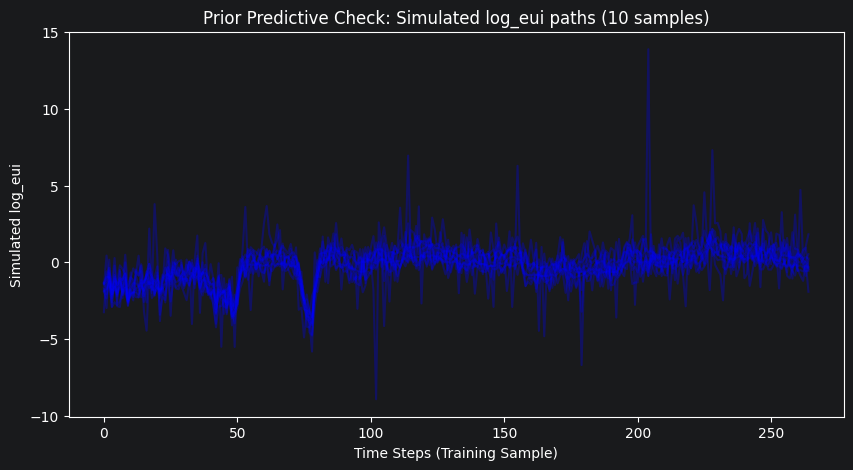

In [27]:
# --- 4. Prior Predictive Check ---
with informed_ar2_model:
    prior_pc = pm.sample_prior_predictive(samples=500, random_seed=6)

plt.figure(figsize=(10, 5))

# Plot the simulated 'obs' data from the priors
# This allows you to check if the range of log_eui stays physically plausible.
for i in range(10):
    plt.plot(prior_pc.prior_predictive["obs"][0, i, :], color="blue", alpha=0.3)

plt.title("Prior Predictive Check: Simulated log_eui paths (10 samples)")
plt.xlabel("Time Steps (Training Sample)")
plt.ylabel("Simulated log_eui")
plt.show()

now we implement the MCMC

In [28]:
with informed_ar2_model:
    # We use NUTS sampling to explore the posterior distribution
    idata_informed = pm.sample(
        draws=1000,
        tune=500,
        chains=4,
        target_accept=0.9,
        random_seed=6,
        progressbar=True
    )

# --- Extract posterior draws for future cells ---
post_inf = idata_informed.posterior
c_draws    = post_inf["c"].values.flatten()
phi1_draws = post_inf["phi1"].values.flatten()
phi2_draws = post_inf["phi2"].values.flatten()
phi3_draws = post_inf["phi3"].values.flatten()
sigma_draws = post_inf["sigma"].values.flatten()

print("Informed model sampling complete and draws extracted.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [c, phi1, phi2, phi3, sigma, nu]


Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 910 seconds.


Informed model sampling complete and draws extracted.


Convergence Diagnostics
You must check if the NUTS sampler actually converged on a stable solution. If the chains didn't "mix" well, your forecasts will be unreliable.
1. R-hat ($\hat{R}$): Should be extremely close to 1.00.
2. ESS (Effective Sample Size): Should ideally be $> 400$ per chain to ensure you have enough independent samples.
3. Trace Plots: You want to see "fuzzy caterpillars," not distinct lines or trends.

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
c      0.006  0.016  -0.026    0.035        0.0    0.000    5182.0    2818.0   
phi1   0.559  0.030   0.504    0.614        0.0    0.000    3567.0    2846.0   
phi2   0.207  0.030   0.150    0.261        0.0    0.001    4551.0    2872.0   
sigma  0.194  0.018   0.159    0.227        0.0    0.000    4252.0    2939.0   

       r_hat  
c        1.0  
phi1     1.0  
phi2     1.0  
sigma    1.0  


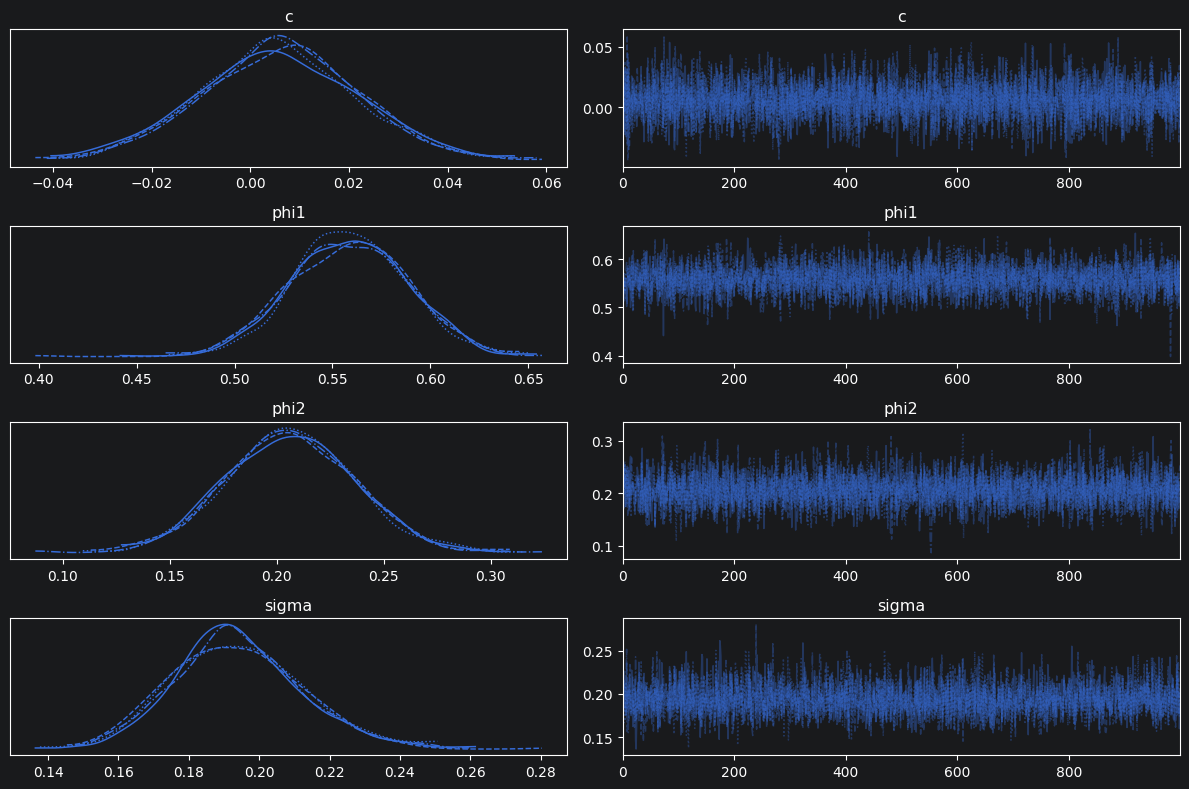

In [29]:
# Check the numbers
print(az.summary(idata_informed, var_names=["c", "phi1", "phi2", "sigma"]))

# Check the visuals
az.plot_trace(idata_informed, var_names=["c", "phi1", "phi2", "sigma"])
plt.tight_layout()
plt.show()

Posterior Predictive Check (PPC)
Earlier, we did a Prior Predictive Check. Now we do a Posterior check. This asks: "If I use the parameters the model just learned, can it recreate data that looks like my actual training data?"

Sampling: [obs]


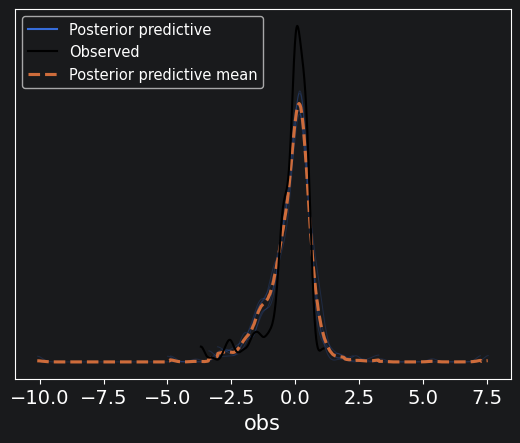

In [33]:
with informed_ar2_model:
    # Generate data from the POSTERIOR
    ppc = pm.sample_posterior_predictive(idata_informed)

# Plot the real data vs. the model's version
az.plot_ppc(ppc, num_pp_samples=5)
plt.show()

In [31]:
# 1. Calculate point estimates (Posterior Means)
c_pm     = float(post_inf["c"].values.mean())
phi1_pm  = float(post_inf["phi1"].values.mean())
phi2_pm  = float(post_inf["phi2"].values.mean())
phi3_pm  = float(post_inf["phi3"].values.mean())
sigma_pm = float(post_inf["sigma"].values.mean())

mu_in = (c_pm +
         phi1_pm * y_train_np[2:-1] +
         phi2_pm * y_train_np[1:-2] +
         phi3_pm * y_train_np[0:-3])

# 3. Calculate residuals (Actual - Predicted)
# We align with the target starting at index 3
resid_in = y_train_np[3:] - mu_in

# 4. Diagnostics: Ljung-Box check
lb_results = acorr_ljungbox(resid_in, lags=[12, 24], return_df=True)
print("Ljung-Box Test on AR(3) Residuals:")
print(lb_results)

Ljung-Box Test on AR(3) Residuals:
       lb_stat     lb_pvalue
12   84.043034  6.950063e-13
24  100.543401  2.426721e-11
